# 📊 Exploratory Data Analysis — Intelligent Support Ticket Classification with RAG

This notebook performs a thorough EDA on the preprocessed support ticket corpus.
The analysis covers:
1. **Data Overview & Shape** — structural sanity checks
2. **Class Frequencies** — category & priority distributions
3. **Text Length Analysis** — critical for choosing transformer `max_length`
4. **Metadata Insights** — channel, severity, and satisfaction distributions

> **Dataset:** `support_tickets_preprocessed.csv`


## 0 · Imports & Global Style

In [1]:
# ── Standard library ──────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

# ── Data ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Global aesthetics ─────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titleweight":  "bold",
    "axes.titlesize":    14,
    "axes.labelsize":    12,
})

# ── Colour palettes ───────────────────────────────────────────────
CAT_PALETTE  = "Set2"
PRIO_PALETTE = {"low": "#4CAF50", "medium": "#FF9800", "high": "#F44336"}
DIST_COLOR   = "#5C85D6"

print("✅  All imports successful.")


Matplotlib is building the font cache; this may take a moment.


✅  All imports successful.


## 1 · Data Overview & Shape

Load the preprocessed CSV and perform structural sanity checks before any analysis.


In [2]:
# ── Load ──────────────────────────────────────────────────────────
DATA_PATH = "raw/support_tickets_preprocessed.csv"
df = pd.read_csv(DATA_PATH)

print(f"Shape  : {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
print(f"Memory : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB\n")
df.head(3)


Shape  : 1,000 rows  ×  24 columns
Memory : 2.10 MB



,ticket_id,created_at,resolved_at,channel,agent_id,category,priority,status,subject,body,...,language,region,severity,tags,root_cause,knowledge_article,customer_satisfaction,conversation,text,clean_text
0,TK-000222,2026-04-07 13:04:13,2026-04-07 15:04:13,phone_callback,AGT-014,shipping,medium,resolved,Package arrived damaged,The tracking for order #30041 has been stuck o...,...,Arabic,Germany,Critical,shipping,Courier delay,"Track shipment, contact courier, arrange repla...",5.0,Customer: The tracking for order #30041 has be...,Package arrived damaged The tracking for order...,package arrived damaged the tracking for order...
1,TK-000775,2026-04-16 13:29:24,2026-04-19 06:29:24,email,AGT-001,shipping,medium,resolved,Tracking number not updating,I received a completely wrong item. I ordered ...,...,English,USA,Critical,shipping,Courier delay,"Track shipment, contact courier, arrange repla...",5.0,Customer: I received a completely wrong item. ...,Tracking number not updating I received a comp...,tracking number not updating i received a comp...
2,TK-000831,2026-03-27 20:21:57,2026-03-27 23:21:57,email,AGT-015,general,low,resolved,Looking for a case study or demo,I came across your service online and want to ...,...,Arabic,UAE,Minor,general,Customer information request,Answer customer inquiry using the official kno...,3.0,Customer: I came across your service online an...,Looking for a case study or demo I came across...,looking for a case study or demo i came across...


In [3]:
# ── Schema / dtypes ───────────────────────────────────────────────
df.info(verbose=True, show_counts=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ticket_id              1000 non-null   object 
 1   created_at             1000 non-null   object 
 2   resolved_at            649 non-null    object 
 3   channel                1000 non-null   object 
 4   agent_id               1000 non-null   object 
 5   category               1000 non-null   object 
 6   priority               1000 non-null   object 
 7   status                 1000 non-null   object 
 8   subject                1000 non-null   object 
 9   body                   1000 non-null   object 
 10  resolution_note        1000 non-null   object 
 11  word_count             1000 non-null   int64  
 12  product                1000 non-null   object 
 13  company                1000 non-null   object 
 14  language               1000 non-null   object 
 15  regio

In [4]:
# ── Null audit ────────────────────────────────────────────────────
null_report = (
    df.isnull().sum()
      .rename("null_count")
      .to_frame()
      .assign(null_pct=lambda x: (x["null_count"] / len(df) * 100).round(2))
      .sort_values("null_count", ascending=False)
)
null_report[null_report["null_count"] > 0]


,null_count,null_pct
resolved_at,351,35.1


In [5]:
# ── Duplicate check ───────────────────────────────────────────────
n_dup = df.duplicated(subset=["ticket_id"]).sum()
print(f"Duplicate ticket_ids : {n_dup}")

n_dup_text = df.duplicated(subset=["clean_text"]).sum()
print(f"Duplicate clean_text : {n_dup_text}")

# ── Quick descriptive stats for numeric columns ───────────────────
df.describe(include="all").T


Duplicate ticket_ids : 0
Duplicate clean_text : 40


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ticket_id,1000,1000,TK-000222,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
created_at,1000,1000,2026-04-07 13:04:13,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
resolved_at,649,649,2026-04-07 15:04:13,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel,1000,5,phone_callback,215,NaN,NaN,NaN,NaN,NaN,NaN,NaN
agent_id,1000,20,AGT-005,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,1000,6,technical,213,NaN,NaN,NaN,NaN,NaN,NaN,NaN
priority,1000,3,medium,378,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status,1000,5,resolved,447,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subject,1000,164,Login page returns 500 error,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
body,1000,709,I updated my billing address last week but my ...,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2 · Class Frequencies — Target Variable Analysis

### 2a · Category Distribution
Understanding class balance is essential before training any classifier.
Severe imbalance → may require oversampling / class-weight adjustments.


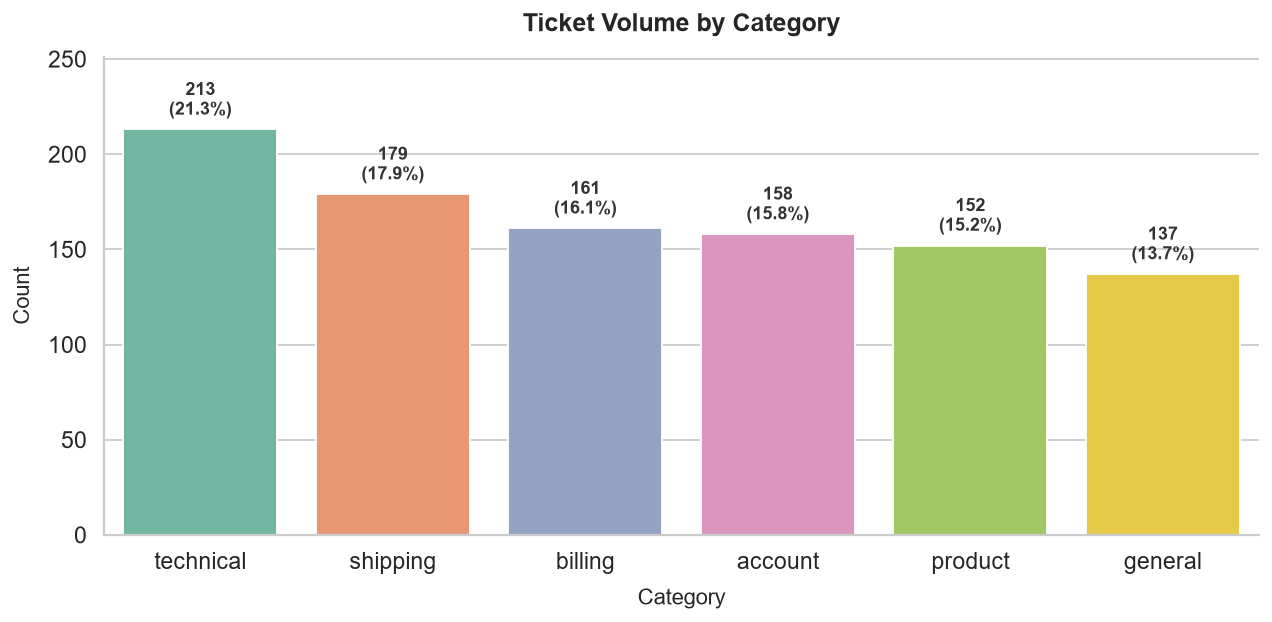

category
technical    213
shipping     179
billing      161
account      158
product      152
general      137
Name: count, dtype: int64


In [6]:
def annotated_barplot(ax, series, palette, title, xlabel, ylabel="Count"):
    """
    Draw a count bar plot with percentage annotations on each bar.
    Works with both a str palette name and a dict palette.
    """
    order  = series.value_counts().index.tolist()
    counts = series.value_counts()
    total  = len(series)

    if isinstance(palette, dict):
        colors = [palette.get(c, "#999999") for c in order]
        sns.barplot(x=order, y=counts.loc[order].values, palette=colors, ax=ax, order=order)
    else:
        sns.countplot(data=series.to_frame(name="val"), x="val", order=order,
                      palette=palette, ax=ax)

    for patch in ax.patches:
        h = patch.get_height()
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            h + total * 0.005,
            f"{h:,.0f}\n({h/total*100:.1f}%)",
            ha="center", va="bottom", fontsize=10, fontweight="bold", color="#333333"
        )

    ax.set_title(title, pad=14)
    ax.set_xlabel(xlabel, labelpad=8)
    ax.set_ylabel(ylabel, labelpad=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.margins(y=0.18)
    return ax

# ── Category bar plot ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
annotated_barplot(
    ax, df["category"], CAT_PALETTE,
    title="Ticket Volume by Category",
    xlabel="Category"
)
plt.tight_layout()
plt.savefig("plot_category_distribution.png", bbox_inches="tight")
plt.show()
print(df["category"].value_counts())


### 2b · Priority Distribution

Priority is an ordinal target (low → medium → high).
The colour coding (green/orange/red) mirrors real-world triage conventions.


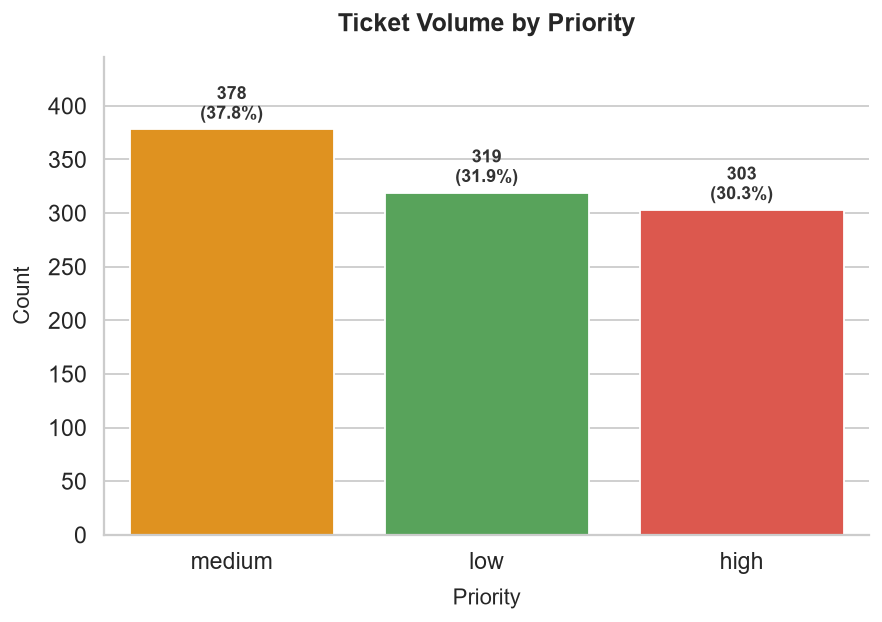

priority
low       319
medium    378
high      303
Name: count, dtype: int64


In [7]:
# ── Priority bar plot ─────────────────────────────────────────────
priority_order = ["low", "medium", "high"]
df["priority"] = pd.Categorical(df["priority"], categories=priority_order, ordered=True)

fig, ax = plt.subplots(figsize=(7, 5))
annotated_barplot(
    ax, df["priority"], PRIO_PALETTE,
    title="Ticket Volume by Priority",
    xlabel="Priority"
)
plt.tight_layout()
plt.savefig("plot_priority_distribution.png", bbox_inches="tight")
plt.show()
print(df["priority"].value_counts().sort_index())


### 2c · Category × Priority Cross-tabulation

Reveals whether certain categories tend to generate higher-priority tickets —
a useful feature engineering signal.


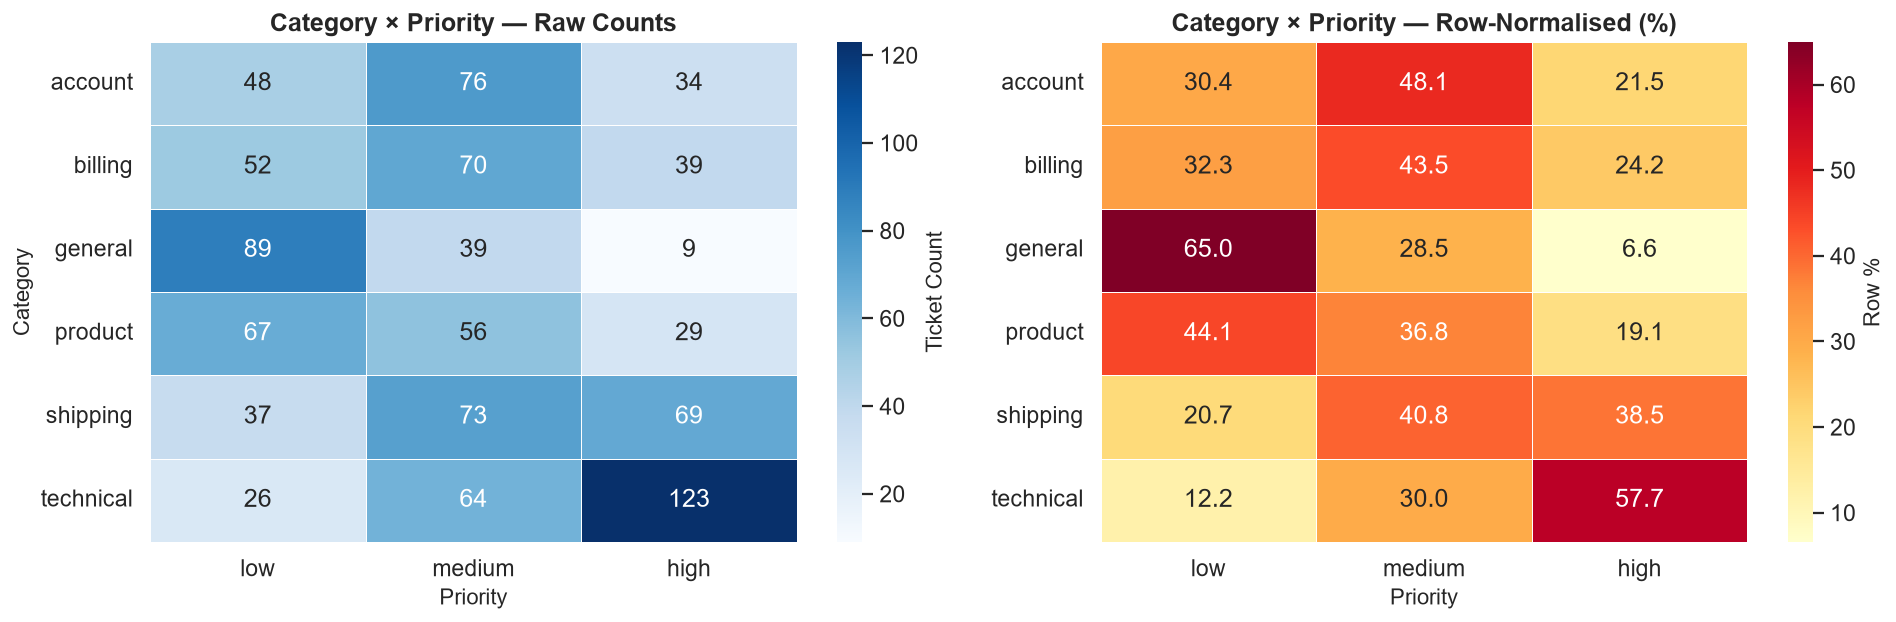

In [8]:
# ── Cross-tab heatmap ─────────────────────────────────────────────
cross = pd.crosstab(df["category"], df["priority"])
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100   # row-normalised %

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Raw counts
sns.heatmap(cross, annot=True, fmt="d", cmap="Blues",
            linewidths=0.5, ax=axes[0], cbar_kws={"label": "Ticket Count"})
axes[0].set_title("Category × Priority — Raw Counts")
axes[0].set_xlabel("Priority"); axes[0].set_ylabel("Category")

# Row-normalised %
sns.heatmap(cross_pct, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=axes[1], cbar_kws={"label": "Row %"})
axes[1].set_title("Category × Priority — Row-Normalised (%)")
axes[1].set_xlabel("Priority"); axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("plot_category_priority_heatmap.png", bbox_inches="tight")
plt.show()


## 3 · Text Length Analysis

The token / word count of `clean_text` is the **most operationally critical metric** in this EDA.
It directly determines the `max_length` you should set when tokenizing for BERT-family models:

| Transformer family | Common `max_length` options |
|---|---|
| BERT / RoBERTa | 128, 256, 512 |
| sentence-transformers | 128, 256, 384 |
| Longformer / BigBird | up to 4,096 |

> **Rule of thumb:** set `max_length` ≥ the **95th percentile** of your token distribution
> to capture ≥95 % of tickets without truncation.


In [9]:
# ── Compute word count from clean_text ────────────────────────────
df["text_word_count"] = df["clean_text"].astype(str).str.split().str.len()

# ── Approximate sub-word token count (words × 1.3 is a heuristic for
#    WordPiece / BPE tokenisers; replace with actual tokeniser if available)
df["approx_token_count"] = (df["text_word_count"] * 1.3).astype(int)

# ── Summary statistics ────────────────────────────────────────────
pcts = [25, 50, 75, 90, 95, 99]
stats = {
    "count":           df["text_word_count"].count(),
    "mean":            df["text_word_count"].mean(),
    "std":             df["text_word_count"].std(),
    "min":             df["text_word_count"].min(),
    "max":             df["text_word_count"].max(),
    **{f"p{p}":        df["text_word_count"].quantile(p/100) for p in pcts},
}

print("=" * 45)
print("  Text Length (word count) — Summary Stats")
print("=" * 45)
for k, v in stats.items():
    print(f"  {k:<10} {v:>10.1f}")
print("=" * 45)

approx_95_tokens = df["approx_token_count"].quantile(0.95)
print(f"\n🔑  Recommended max_length for transformer : {int(approx_95_tokens)} tokens  (95th-pct approx sub-word)")


  Text Length (word count) — Summary Stats
  count          1000.0
  mean             30.3
  std               6.0
  min              15.0
  max              46.0
  p25              25.0
  p50              31.0
  p75              35.0
  p90              38.0
  p95              40.0
  p99              42.0

🔑  Recommended max_length for transformer : 52 tokens  (95th-pct approx sub-word)


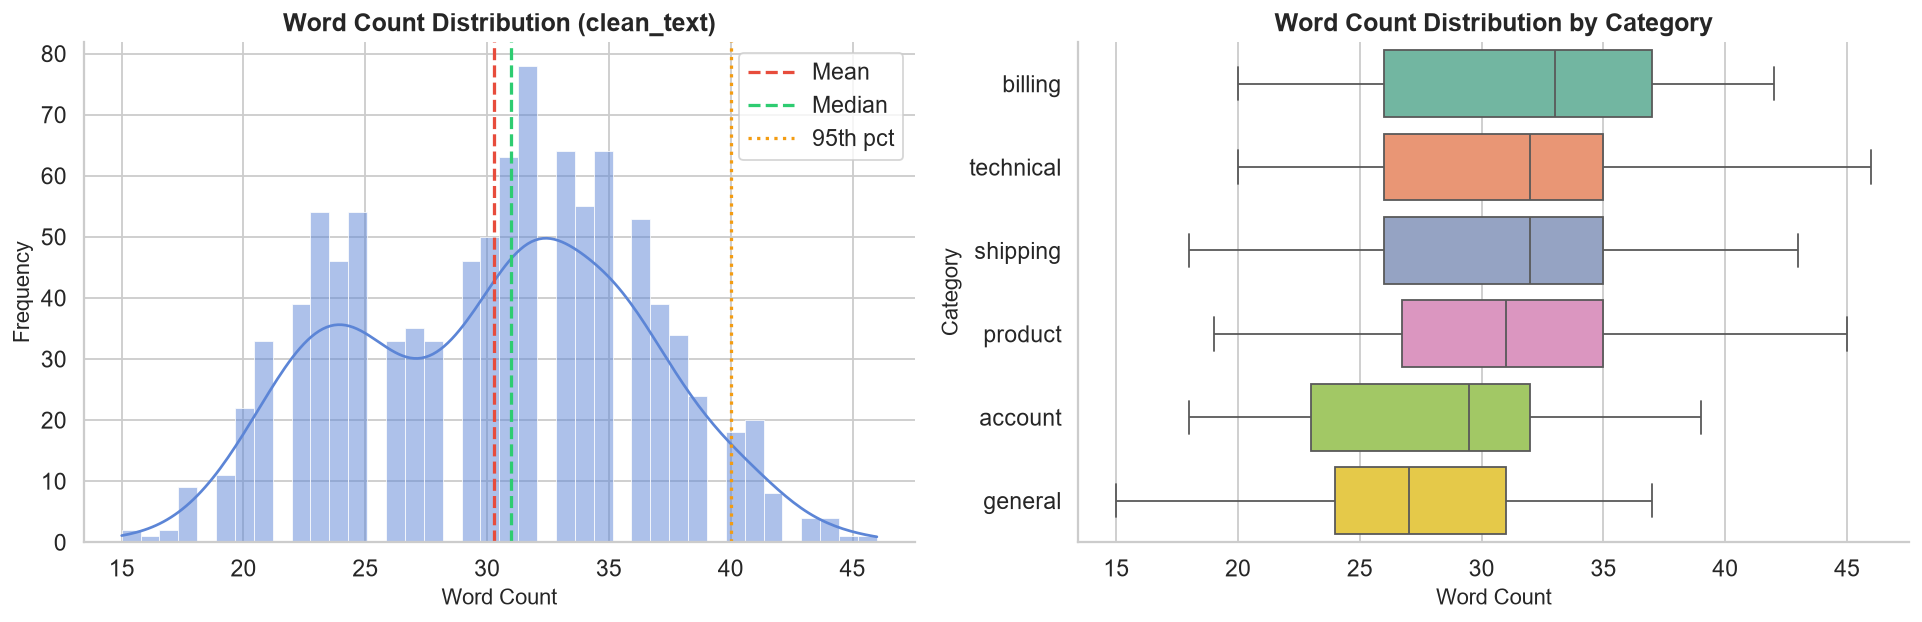

In [10]:
# ── Histogram + KDE of word counts ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: histogram with KDE overlay
ax = axes[0]
sns.histplot(df["text_word_count"], bins=40, kde=True,
             color=DIST_COLOR, ax=ax, edgecolor="white", linewidth=0.4)
ax.axvline(df["text_word_count"].mean(),   color="#E74C3C", lw=1.8, ls="--", label="Mean")
ax.axvline(df["text_word_count"].median(), color="#2ECC71", lw=1.8, ls="--", label="Median")
ax.axvline(df["text_word_count"].quantile(0.95), color="#F39C12", lw=1.8, ls=":", label="95th pct")
ax.set_title("Word Count Distribution (clean_text)")
ax.set_xlabel("Word Count"); ax.set_ylabel("Frequency")
ax.legend()

# Right: box plot per category
ax2 = axes[1]
cat_order = df.groupby("category")["text_word_count"].median().sort_values(ascending=False).index
sns.boxplot(data=df, y="category", x="text_word_count",
            order=cat_order, palette=CAT_PALETTE, ax=ax2,
            flierprops={"marker": "o", "markersize": 3, "alpha": 0.4})
ax2.set_title("Word Count Distribution by Category")
ax2.set_xlabel("Word Count"); ax2.set_ylabel("Category")

plt.tight_layout()
plt.savefig("plot_text_length_distribution.png", bbox_inches="tight")
plt.show()


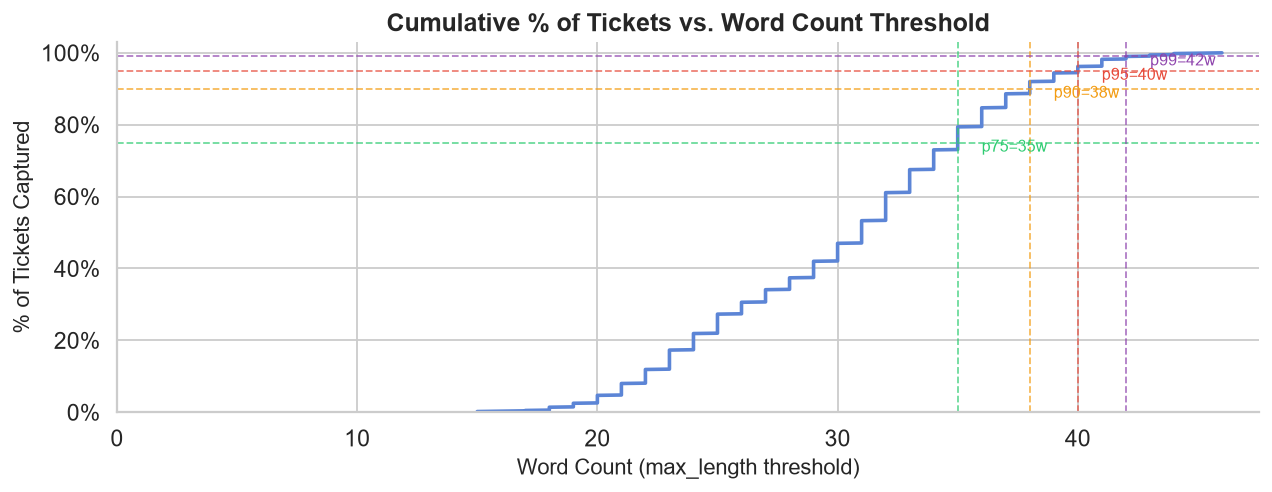

In [11]:
# ── Cumulative % chart — helps choose max_length cut-off ─────────
fig, ax = plt.subplots(figsize=(10, 4))
sorted_wc = np.sort(df["text_word_count"].values)
cumulative = np.arange(1, len(sorted_wc) + 1) / len(sorted_wc) * 100

ax.plot(sorted_wc, cumulative, color=DIST_COLOR, lw=2)

for pct, color in [(75, "#2ECC71"), (90, "#F39C12"), (95, "#E74C3C"), (99, "#8E44AD")]:
    val = np.percentile(sorted_wc, pct)
    ax.axhline(pct, color=color, lw=1, ls="--", alpha=0.7)
    ax.axvline(val, color=color, lw=1, ls="--", alpha=0.7)
    ax.text(val + 1, pct - 2.5, f"p{pct}={int(val)}w", color=color, fontsize=9)

ax.set_title("Cumulative % of Tickets vs. Word Count Threshold")
ax.set_xlabel("Word Count (max_length threshold)")
ax.set_ylabel("% of Tickets Captured")
ax.set_xlim(left=0)
ax.set_ylim(0, 103)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.savefig("plot_cumulative_text_length.png", bbox_inches="tight")
plt.show()


## 4 · Metadata Insights

Quick look at ticket distribution across operational dimensions:
- **Channel** — where customers raise tickets (email, chat, web form …)
- **Severity** — internal severity score vs. customer-assigned priority
- **Customer Satisfaction** — outcome quality signal for model evaluation
- **Status** — operational backlog view


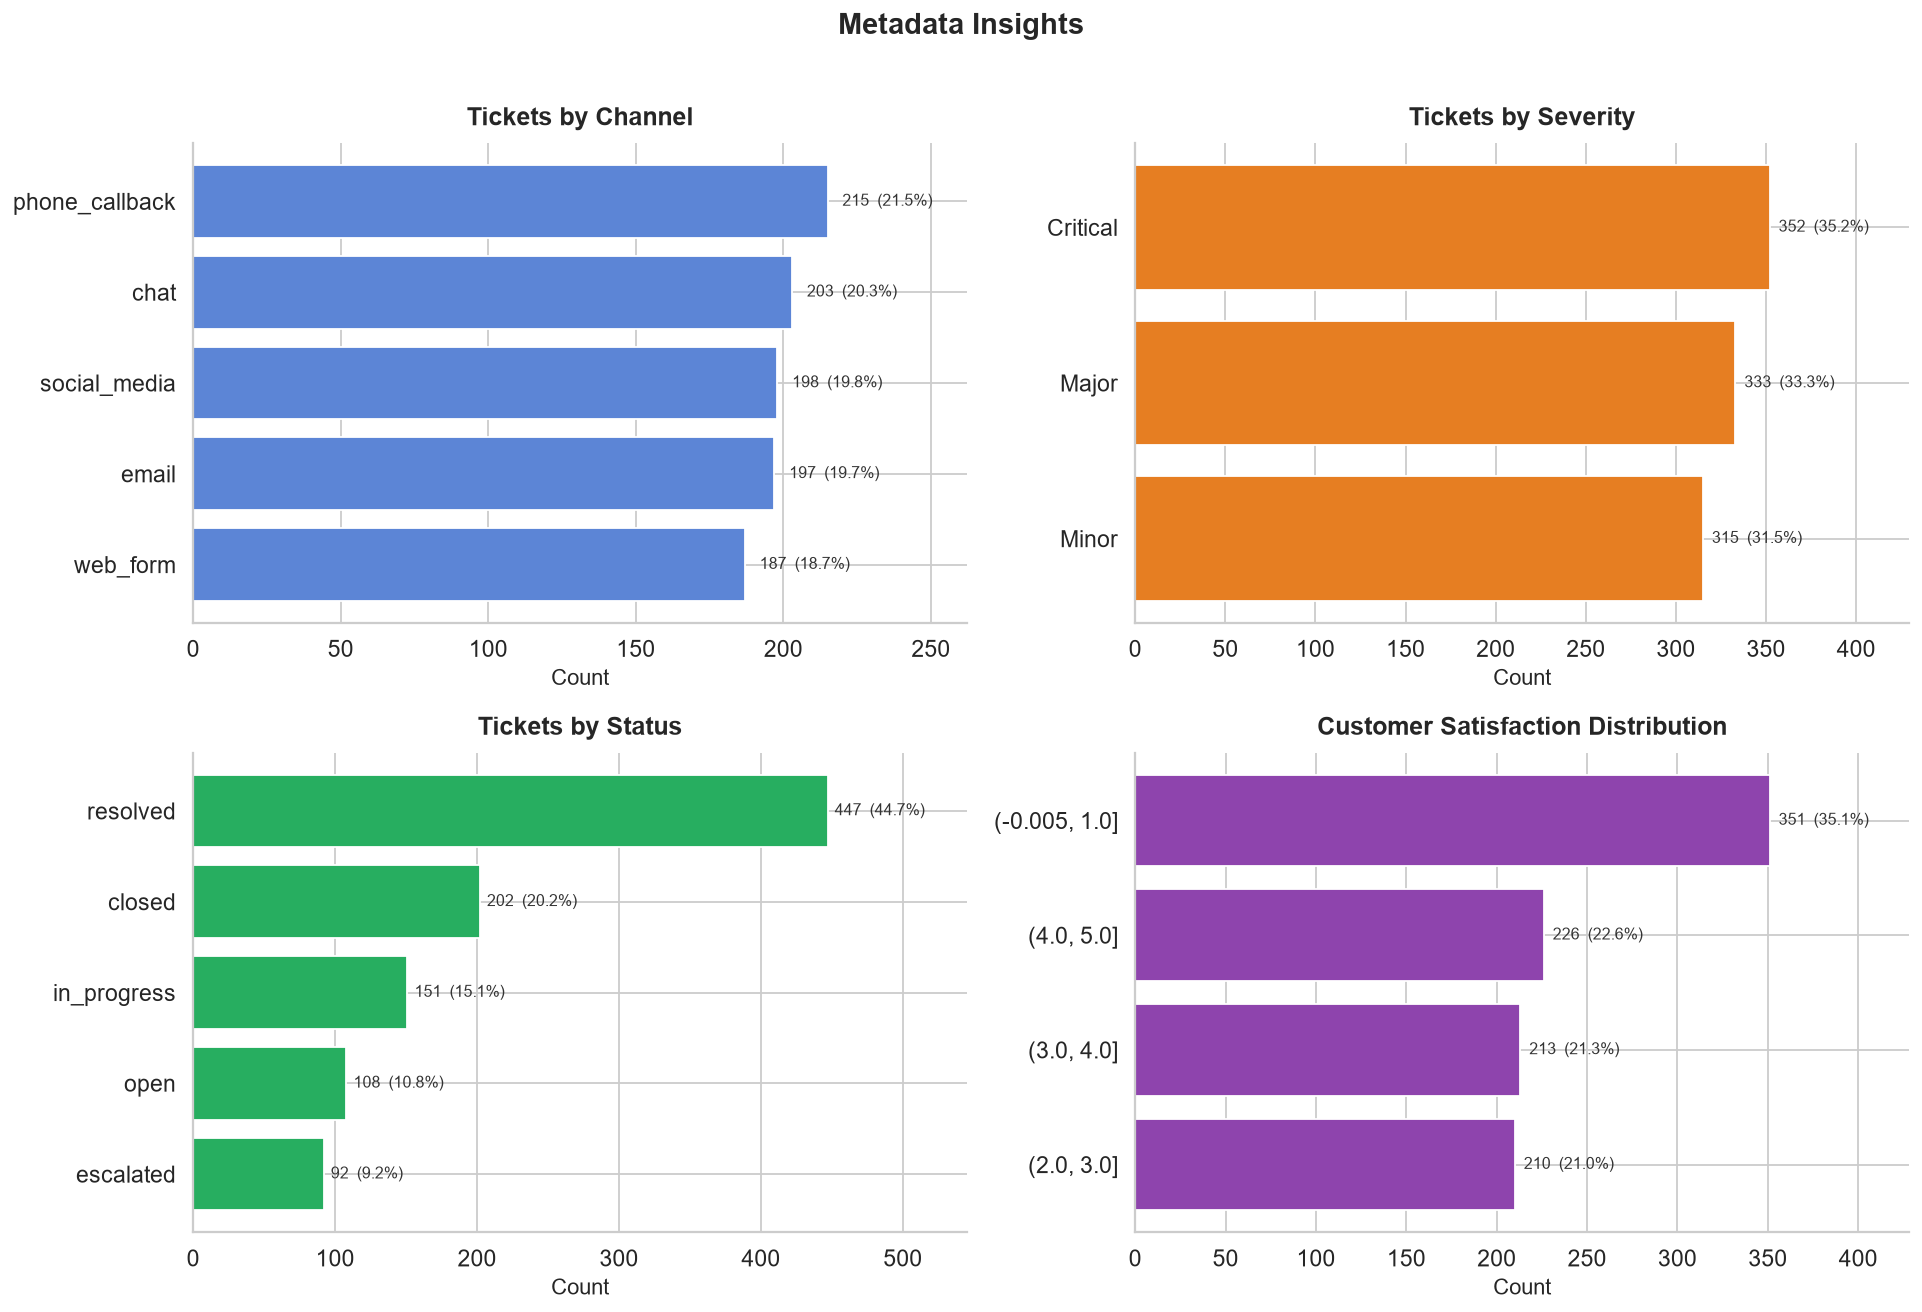

In [12]:
# ── Helper: plot a horizontal bar chart with % labels ─────────────
def h_barplot(series, ax, title, color="#5C85D6", top_n=None):
    counts = series.value_counts()
    if top_n:
        counts = counts.head(top_n)
    total = counts.sum()
    bars = ax.barh(counts.index[::-1], counts.values[::-1], color=color, edgecolor="white")
    for bar, val in zip(bars, counts.values[::-1]):
        ax.text(bar.get_width() + total * 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val:,}  ({val/total*100:.1f}%)",
                va="center", ha="left", fontsize=9, color="#333333")
    ax.set_title(title, pad=10)
    ax.set_xlabel("Count")
    ax.margins(x=0.22)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    return ax

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Channel
h_barplot(df["channel"], axes[0, 0], "Tickets by Channel", color="#5C85D6")

# Severity
h_barplot(df["severity"], axes[0, 1], "Tickets by Severity", color="#E67E22")

# Status
h_barplot(df["status"], axes[1, 0], "Tickets by Status", color="#27AE60")

# Customer satisfaction (numeric → bin if needed)
if pd.api.types.is_numeric_dtype(df["customer_satisfaction"]):
    bins = pd.cut(df["customer_satisfaction"], bins=5)
    h_barplot(bins.astype(str), axes[1, 1], "Customer Satisfaction Distribution", color="#8E44AD")
else:
    h_barplot(df["customer_satisfaction"], axes[1, 1], "Customer Satisfaction Distribution", color="#8E44AD")

plt.suptitle("Metadata Insights", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plot_metadata_insights.png", bbox_inches="tight")
plt.show()


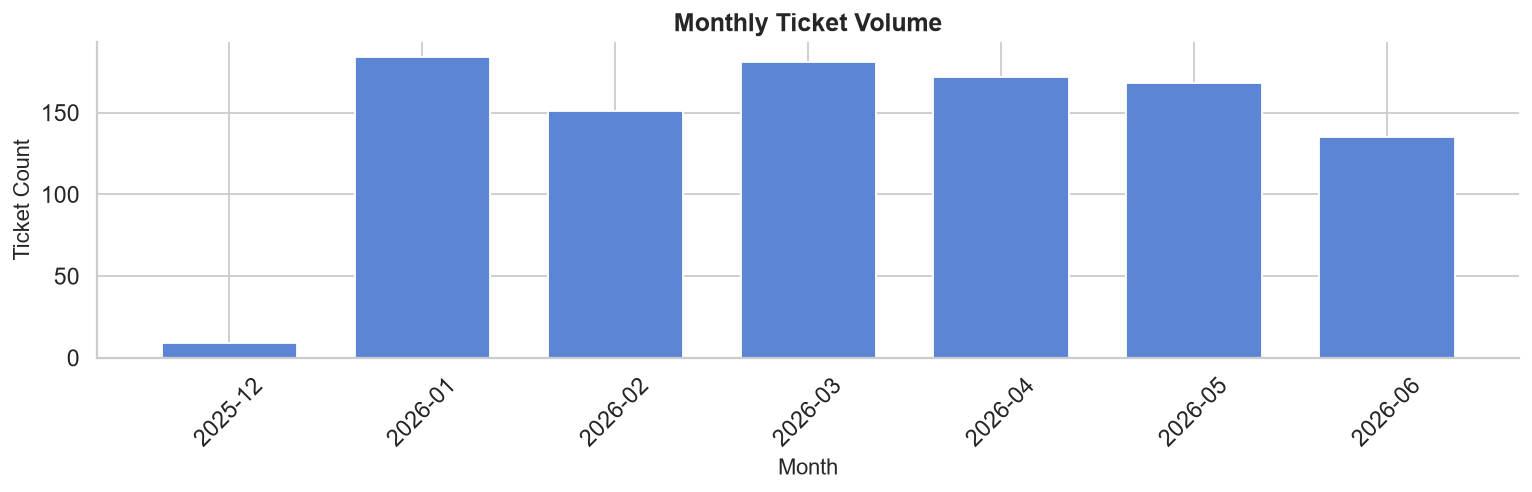

In [13]:
# ── Ticket volume over time ────────────────────────────────────────
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")
df["month"] = df["created_at"].dt.to_period("M")

monthly = df.groupby("month").size().reset_index(name="count")
monthly["month_str"] = monthly["month"].astype(str)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly["month_str"], monthly["count"], color=DIST_COLOR, edgecolor="white", width=0.7)
ax.set_title("Monthly Ticket Volume")
ax.set_xlabel("Month"); ax.set_ylabel("Ticket Count")
ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("plot_monthly_volume.png", bbox_inches="tight")
plt.show()


## 5 · EDA Summary & Recommendations for Milestone 2

| Finding | Action |
|---|---|
| Class imbalance in `category` | Use `class_weight='balanced'` or stratified sampling |
| Priority skew (low/medium dominant) | Consider binary collapse (low+medium vs. high) as an alternative target |
| 95th-pct word count | Set transformer `max_length` accordingly (printed in Cell 3) |
| Channel distribution | Add `channel` as a categorical feature — strong signal |
| Severity vs. Priority correlation | Check Cramér's V; if high, use one to avoid multicollinearity |
| Resolved tickets have `resolution_note` | Use this column as ground-truth response for RAG retrieval |


In [14]:
# ── Final quick Cramér's V between category and severity ──────────
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.values.sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

pairs = [
    ("category", "priority"),
    ("category", "severity"),
    ("priority", "severity"),
    ("category", "channel"),
]

print("Cramér's V (association strength between categorical variables)")
print("-" * 55)
for a, b in pairs:
    if a in df.columns and b in df.columns:
        v = cramers_v(df[a].astype(str), df[b].astype(str))
        strength = "strong" if v > 0.5 else "moderate" if v > 0.3 else "weak"
        print(f"  {a:<15} × {b:<15}  V = {v:.3f}  [{strength}]")


Cramér's V (association strength between categorical variables)
-------------------------------------------------------
  category        × priority         V = 0.312  [moderate]
  category        × severity         V = 0.077  [weak]
  priority        × severity         V = 0.051  [weak]
  category        × channel          V = 0.057  [weak]


In [1]:
import os
import shutil

# 1. تحديد اسم المجلد الجديد
target_folder = 'graphs'

# 2. إنشاء المجلد إذا لم يكن موجوداً بالفعل
if not os.path.exists(target_folder):
    os.makedirs(target_folder)
    print(f"تم إنشاء المجلد: '{target_folder}' بنجاح.")

# 3. جرد جميع الملفات في المجلد الحالي ونقل ملفات الـ png
moved_count = 0
for file_name in os.listdir('.'):
    # التأكد من أن الملف ينتهي بـ .png وأنه ملف وليس مجلد
    if file_name.endswith('.png') and os.path.isfile(file_name):
        src_path = file_name
        dst_path = os.path.join(target_folder, file_name)
        
        # نقل الملف
        shutil.move(src_path, dst_path)
        print(f"تم نقل: {file_name} -> {target_folder}/")
        moved_count += 1

print(f"\n✨ العملية تمت بنجاح! تم نقل {moved_count} صور إلى مجلد '{target_folder}'.")

تم نقل: plot_category_distribution.png -> graphs/
تم نقل: plot_category_priority_heatmap.png -> graphs/
تم نقل: plot_cumulative_text_length.png -> graphs/
تم نقل: plot_metadata_insights.png -> graphs/
تم نقل: plot_monthly_volume.png -> graphs/
تم نقل: plot_priority_distribution.png -> graphs/
تم نقل: plot_text_length_distribution.png -> graphs/

✨ العملية تمت بنجاح! تم نقل 7 صور إلى مجلد 'graphs'.
